In [1]:
!pip install transformers torch scikit-learn lime matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=597217844c54603540c5550d50a52b08e9766af86bd6f4e44fe14ef8456e1970
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 1: IMPORTS AND CONFIGURATION                            ║
# ╚═══════════════════════════════════════════════════════════════╝

import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertModel,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")


class Config:
    DATASET_PATH = "/content/drive/MyDrive/00 MalBert - Internship Project/00_final_dataset_multiview.csv"
    OUTPUT_DIR = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results"
    MODEL_SAVE_DIR = "/content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models/fusion_comparison"
    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

    # Fusion strategy to test — change this before each run
    # Options: "cross_attention", "concat", "mean"
    FUSION_STRATEGY = "mean"   # <-- change this

    BERT_MODEL = "distilbert-base-uncased"
    MAX_SEQ_LENGTH = 512
    HIDDEN_DIM = 768
    FUSION_HEADS = 8
    FUSION_LAYERS = 2
    DROPOUT = 0.3

    BATCH_SIZE = 8
    EPOCHS = 5               # Reduced from 15 — sufficient for BERT fine-tuning
    LEARNING_RATE = 3e-5      # Slightly higher to learn faster in fewer epochs
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.15       # Slightly more warmup to stabilize early training
    GRADIENT_CLIP = 1.0

    BINARY_LOSS_WEIGHT = 0.6
    FAMILY_LOSS_WEIGHT = 0.4

    SEED = 42

    VIEWS = ["PERM", "API", "INTENT", "OPCODE"]
    NUM_VIEWS = 4

    FAMILIES = []
    NUM_FAMILIES = 0


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(Config.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
os.makedirs(Config.MODEL_SAVE_DIR, exist_ok=True)

print("All imports loaded successfully!")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Epochs: {Config.EPOCHS}, LR: {Config.LEARNING_RATE}, Warmup: {Config.WARMUP_RATIO}")

All imports loaded successfully!
Device: cuda
GPU: Tesla T4
Epochs: 5, LR: 3e-05, Warmup: 0.15


In [4]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 2: MOUNT GOOGLE DRIVE AND VERIFY DATASET                ║
# ╚═══════════════════════════════════════════════════════════════╝

import shutil
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)


# Verify dataset exists
print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

if os.path.exists(Config.DATASET_PATH):
    size_mb = os.path.getsize(Config.DATASET_PATH) / (1024 * 1024)
    print(f"  Dataset FOUND: {Config.DATASET_PATH}")
    print(f"  Size: {size_mb:.1f} MB")

    # Quick peek
    df_peek = pd.read_csv(Config.DATASET_PATH, encoding="latin-1",
                           on_bad_lines="skip", engine="python", nrows=5)
    print(f"  Columns: {df_peek.columns.tolist()}")
    print(f"  Format: {'Multi-view (separate columns)' if 'PERM' in df_peek.columns else 'Merged text'}")
else:
    print(f"  DATASET NOT FOUND: {Config.DATASET_PATH}")
    print("  Check the path and re-run!")

# Create output directories on Drive (survives runtime reset)
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
os.makedirs(Config.MODEL_SAVE_DIR, exist_ok=True)
print(f"\n  Results dir: {Config.OUTPUT_DIR}")
print(f"  Model dir:   {Config.MODEL_SAVE_DIR}")

Mounted at /content/drive
DATASET VERIFICATION
  Dataset FOUND: /content/drive/MyDrive/00 MalBert - Internship Project/00_final_dataset_multiview.csv
  Size: 291.3 MB
  Columns: ['file_name', 'family', 'PERM', 'API', 'INTENT', 'OPCODE']
  Format: Multi-view (separate columns)

  Results dir: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results
  Model dir:   /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models/fusion_comparison


In [5]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 3: LOAD AND PREPROCESS DATA                             ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[1/6] Loading and preprocessing data...")
print("=" * 60)

# Load CSV with encoding fix
df = pd.read_csv(Config.DATASET_PATH, encoding="latin-1", on_bad_lines="skip", engine="python")
print(f"Loaded dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Handle merged format (single 'text' column)
if "text" in df.columns and "PERM" not in df.columns:
    print("\nDetected merged format. Splitting 'text' back into views...")

    def split_text_to_views(text):
        if not isinstance(text, str):
            return {"PERM": "", "API": "", "INTENT": "", "OPCODE": ""}
        views = {}
        perm_match = re.search(r"PERM:\s*(.*?)\s*API:", text, re.DOTALL)
        views["PERM"] = perm_match.group(1).strip() if perm_match else ""
        api_match = re.search(r"API:\s*(.*?)\s*INTENT:", text, re.DOTALL)
        views["API"] = api_match.group(1).strip() if api_match else ""
        intent_match = re.search(r"INTENT:\s*(.*?)\s*OPCODE:", text, re.DOTALL)
        views["INTENT"] = intent_match.group(1).strip() if intent_match else ""
        opcode_match = re.search(r"OPCODE:\s*(.*)", text, re.DOTALL)
        views["OPCODE"] = opcode_match.group(1).strip() if opcode_match else ""
        return views

    view_data = df["text"].apply(split_text_to_views).apply(pd.Series)
    df = pd.concat([df.drop(columns=["text"]), view_data], axis=1)
    print("Split complete!")

# Drop unnecessary columns
columns_to_drop = ["apk_size", "permission_count", "api_count", "opcode_count", "intent_count"]
existing_drops = [c for c in columns_to_drop if c in df.columns]
if existing_drops:
    df = df.drop(columns=existing_drops)

# Clean data
df = df.dropna(subset=["family"])
df["family"] = df["family"].replace("Benign3", "Benign")

known_families = ["Banking", "Riskware", "SMS", "Adware", "Benign"]
df = df[df["family"].isin(known_families)].reset_index(drop=True)

# Fill NaN in feature columns
for view in Config.VIEWS:
    if view in df.columns:
        df[view] = df[view].fillna("")
    else:
        df[view] = ""
        print(f"WARNING: Created empty column for missing view: {view}")

# Create labels
df["binary_label"] = (df["family"] != "Benign").astype(int)

label_encoder = LabelEncoder()
df["family_label"] = label_encoder.fit_transform(df["family"])
Config.FAMILIES = list(label_encoder.classes_)
Config.NUM_FAMILIES = len(Config.FAMILIES)

# Print summary
print(f"\nAfter cleaning: {df.shape}")
print(f"Families: {Config.FAMILIES} ({Config.NUM_FAMILIES} classes)")

print(f"\nFamily distribution:")
for family, count in df["family"].value_counts().items():
    binary = 0 if family == "Benign" else 1
    print(f"  {family:12s}: {count:5d}  (binary={binary})")

print(f"\nFeature lengths (words):")
for view in Config.VIEWS:
    lengths = df[view].apply(lambda x: len(x.split()) if x else 0)
    print(f"  {view:8s}:  min={lengths.min():4d}  mean={lengths.mean():7.1f}  max={lengths.max():5d}")

print(f"\nSample data:")
print(df[["family", "binary_label", "family_label"]].head(3))


[1/6] Loading and preprocessing data...
Loaded dataset: (15644, 6)
Columns: ['file_name', 'family', 'PERM', 'API', 'INTENT', 'OPCODE']

After cleaning: (15644, 8)
Families: ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS'] (5 classes)

Family distribution:
  SMS         :  4816  (binary=1)
  Benign      :  3924  (binary=0)
  Riskware    :  2943  (binary=1)
  Banking     :  2463  (binary=1)
  Adware      :  1498  (binary=1)

Feature lengths (words):
  PERM    :  min=   0  mean=   14.5  max=  169
  API     :  min=   0  mean= 1163.4  max=11348
  INTENT  :  min=   0  mean=    7.9  max=  549
  OPCODE  :  min=   0  mean=   67.0  max=  218

Sample data:
   family  binary_label  family_label
0  Adware             1             0
1  Adware             1             0
2  Adware             1             0


In [6]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 4: DATASET CLASS AND DATALOADERS                        ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[2/6] Building datasets and dataloaders...")
print("=" * 60)


class MultiViewMalwareDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        item = {}

        for view in Config.VIEWS:
            text = row[view] if isinstance(row[view], str) else ""
            encoding = self.tokenizer(
                text,
                max_length=self.max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
            item[f"{view}_input_ids"] = encoding["input_ids"].squeeze(0)
            item[f"{view}_attention_mask"] = encoding["attention_mask"].squeeze(0)

        item["binary_label"] = torch.tensor(row["binary_label"], dtype=torch.long)
        item["family_label"] = torch.tensor(row["family_label"], dtype=torch.long)
        return item


# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained(Config.BERT_MODEL)

# Splits: 70% train, 10% val, 20% test
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=Config.SEED, stratify=df["family_label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.125, random_state=Config.SEED, stratify=train_df["family_label"]
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Save train/val/test splits to Drive (useful for reproducibility + thesis)
SPLITS_DIR = os.path.join(os.path.dirname(Config.DATASET_PATH), "splits")
os.makedirs(SPLITS_DIR, exist_ok=True)

train_df.to_csv(os.path.join(SPLITS_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(SPLITS_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(SPLITS_DIR, "test.csv"), index=False)

print(f"Splits saved to: {SPLITS_DIR}")
print(f"  train.csv: {len(train_df)} samples")
print(f"  val.csv:   {len(val_df)} samples")
print(f"  test.csv:  {len(test_df)} samples")

# Create datasets
train_dataset = MultiViewMalwareDataset(train_df, tokenizer, Config.MAX_SEQ_LENGTH)
val_dataset = MultiViewMalwareDataset(val_df, tokenizer, Config.MAX_SEQ_LENGTH)
test_dataset = MultiViewMalwareDataset(test_df, tokenizer, Config.MAX_SEQ_LENGTH)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, num_workers=2, pin_memory=True)

# Quick test
sample = train_dataset[0]
print(f"\nSample check:")
for view in Config.VIEWS:
    print(f"  {view}_input_ids shape: {sample[f'{view}_input_ids'].shape}")
print(f"  binary_label: {sample['binary_label']}")
print(f"  family_label: {sample['family_label']}")
print("\nDataloaders ready!")


[2/6] Building datasets and dataloaders...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 10950, Val: 1565, Test: 3129
Splits saved to: /content/drive/MyDrive/00 MalBert - Internship Project/splits
  train.csv: 10950 samples
  val.csv:   1565 samples
  test.csv:  3129 samples

Sample check:
  PERM_input_ids shape: torch.Size([512])
  API_input_ids shape: torch.Size([512])
  INTENT_input_ids shape: torch.Size([512])
  OPCODE_input_ids shape: torch.Size([512])
  binary_label: 0
  family_label: 2

Dataloaders ready!


In [7]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 5: MODEL ARCHITECTURE                                   ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[3/6] Building MalBERT-XAI model...")
print("=" * 60)


class ConcatFusion(nn.Module):
    """
    Simple Concatenation Fusion.
    4 view embeddings (768-dim each) concatenate karo → project to 768-dim.
    No interaction between views — baseline strategy.
    """
    def __init__(self, hidden_dim, num_views, dropout=0.1):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim * num_views, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim)
        )

    def forward(self, x, return_attention=False):
        # x shape: [batch, num_views, hidden_dim]
        batch_size = x.shape[0]
        # Flatten all views: [batch, num_views * hidden_dim]
        concatenated = x.reshape(batch_size, -1)
        fused = self.projection(concatenated)
        if return_attention:
            # Uniform attention (no learned attention in concat)
            uniform_attn = torch.ones(batch_size, x.shape[1], device=x.device) / x.shape[1]
            return fused, uniform_attn
        return fused


class MeanFusion(nn.Module):
    """
    Mean Pooling Fusion.
    4 view embeddings ka element-wise average — simplest possible fusion.
    Views contribute equally — no learned weighting.
    """
    def __init__(self, hidden_dim, dropout=0.1):
        super().__init__()
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, x, return_attention=False):
        # x shape: [batch, num_views, hidden_dim]
        # Simple average across views
        fused = self.projection(self.layer_norm(x.mean(dim=1)))
        if return_attention:
            # Uniform attention (equal weights)
            uniform_attn = torch.ones(x.shape[0], x.shape[1], device=x.device) / x.shape[1]
            return fused, uniform_attn
        return fused


class CrossAttentionFusion(nn.Module):
    """
    Cross-attention module: each view attends to all other views.
    This captures inter-view correlations (e.g., suspicious permission
    + suspicious API call = higher malware probability).
    """

    def __init__(self, hidden_dim, num_heads, num_layers, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.view_position = nn.Parameter(torch.randn(1, Config.NUM_VIEWS, hidden_dim) * 0.02)
        self.attention_pool = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.Tanh(),
            nn.Linear(hidden_dim // 4, 1),
        )
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, view_embeddings, return_attention=False):
        x = view_embeddings + self.view_position
        x = self.transformer(x)
        attn_scores = self.attention_pool(x)
        attn_weights = F.softmax(attn_scores, dim=1)
        fused = (x * attn_weights).sum(dim=1)
        fused = self.layer_norm(fused)
        if return_attention:
            return fused, attn_weights.squeeze(-1)
        return fused


class MalBERTXAI(nn.Module):
    """
    Multi-View Transformer with Cross-Attention Fusion
    and Hierarchical Classification for Android Malware Detection.

    4x DistilBERT (shared) -> View Projections -> Cross-Attention Fusion
    -> Binary Head (Malware/Benign) + Family Head (multi-class)
    """

    def __init__(self, config):
        super().__init__()
        # Shared DistilBERT backbone
        self.bert = DistilBertModel.from_pretrained(config.BERT_MODEL)

        # View-specific projection layers
        self.view_projections = nn.ModuleDict({
            view: nn.Sequential(
                nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM),
                nn.LayerNorm(config.HIDDEN_DIM),
                nn.GELU(),
                nn.Dropout(config.DROPOUT),
            )
            for view in config.VIEWS
        })

        # Select fusion strategy based on Config
        if Config.FUSION_STRATEGY == "cross_attention":
            self.fusion = CrossAttentionFusion(
                config.HIDDEN_DIM, config.FUSION_HEADS,
                config.FUSION_LAYERS, config.DROPOUT)
        elif Config.FUSION_STRATEGY == "concat":
            self.fusion = ConcatFusion(
                config.HIDDEN_DIM, config.NUM_VIEWS, config.DROPOUT)
        elif Config.FUSION_STRATEGY == "mean":
            self.fusion = MeanFusion(
                config.HIDDEN_DIM, config.DROPOUT)
        else:
            raise ValueError(f"Unknown fusion strategy: {Config.FUSION_STRATEGY}")

        print(f"Fusion strategy: {Config.FUSION_STRATEGY}")

        # Binary classification head (Malware vs Benign)
        self.binary_classifier = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM // 2),
            nn.GELU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.HIDDEN_DIM // 2, 2),
        )

        # Family classification head (multi-class)
        self.family_classifier = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM // 2),
            nn.GELU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.HIDDEN_DIM // 2, config.NUM_FAMILIES),
        )

    def encode_view(self, input_ids, attention_mask, view_name):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        projected = self.view_projections[view_name](cls_embedding)
        return projected

    def forward(self, batch, return_attention=False):
        view_embeddings = []
        for view in Config.VIEWS:
            input_ids = batch[f"{view}_input_ids"]
            attention_mask = batch[f"{view}_attention_mask"]
            emb = self.encode_view(input_ids, attention_mask, view)
            view_embeddings.append(emb)

        stacked = torch.stack(view_embeddings, dim=1)

        if return_attention:
            fused, attn_weights = self.fusion(stacked, return_attention=True)
        else:
            fused = self.fusion(stacked)
            attn_weights = None

        binary_logits = self.binary_classifier(fused)
        family_logits = self.family_classifier(fused)

        if return_attention:
            return binary_logits, family_logits, attn_weights
        return binary_logits, family_logits


# Build model
model = MalBERTXAI(Config).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Model built successfully!")


[3/6] Building MalBERT-XAI model...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fusion strategy: mean
Total parameters:     69,916,807
Trainable parameters: 69,916,807
Model built successfully!


In [ ]:
# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 6: TRAINING                                             ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[4/6] Training...")
print("=" * 60)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Class weights for imbalanced data
binary_counts = train_df["binary_label"].value_counts()
total = len(train_df)
binary_weights = torch.tensor(
    [total / (2 * binary_counts.get(0, 1)), total / (2 * binary_counts.get(1, 1))],
    dtype=torch.float32,
).to(device)

binary_criterion = nn.CrossEntropyLoss(weight=binary_weights)

# Family class weights for imbalanced data
family_counts = train_df["family_label"].value_counts()
family_weight_list = [total / (Config.NUM_FAMILIES * family_counts.get(i, 1))
                      for i in range(Config.NUM_FAMILIES)]
family_weights_tensor = torch.tensor(family_weight_list, dtype=torch.float32).to(device)
family_criterion = nn.CrossEntropyLoss(weight=family_weights_tensor)
print(f"Family weights: {dict(zip(Config.FAMILIES, [f'{w:.2f}' for w in family_weight_list]))}")

# Optimizer with differential learning rates
bert_params = list(model.bert.parameters())
head_params = (
    list(model.view_projections.parameters())
    + list(model.fusion.parameters())
    + list(model.binary_classifier.parameters())
    + list(model.family_classifier.parameters())
)

optimizer = AdamW(
    [
        {"params": bert_params, "lr": Config.LEARNING_RATE},
        {"params": head_params, "lr": Config.LEARNING_RATE * 5},
    ],
    weight_decay=Config.WEIGHT_DECAY,
)

num_training_steps = len(train_loader) * Config.EPOCHS
num_warmup_steps = int(num_training_steps * Config.WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps
)

# Training history
history = {
    "train_loss": [], "val_loss": [],
    "train_binary_acc": [], "val_binary_acc": [],
    "train_family_acc": [], "val_family_acc": [],
    "val_binary_f1": [], "val_family_f1": [],
}

best_val_f1 = 0
patience = 2
patience_counter = 0

for epoch in range(Config.EPOCHS):

    # ── TRAIN ──
    model.train()
    total_loss = 0
    train_bin_preds, train_bin_labels = [], []
    train_fam_preds, train_fam_labels = [], []

    for batch_idx, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        binary_logits, family_logits = model(batch)

        loss_binary = binary_criterion(binary_logits, batch["binary_label"])
        loss_family = family_criterion(family_logits, batch["family_label"])
        loss = Config.BINARY_LOSS_WEIGHT * loss_binary + Config.FAMILY_LOSS_WEIGHT * loss_family

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        train_bin_preds.extend(binary_logits.argmax(dim=1).cpu().tolist())
        train_bin_labels.extend(batch["binary_label"].cpu().tolist())
        train_fam_preds.extend(family_logits.argmax(dim=1).cpu().tolist())
        train_fam_labels.extend(batch["family_label"].cpu().tolist())

        if (batch_idx + 1) % 20 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss = total_loss / len(train_loader)
    train_binary_acc = accuracy_score(train_bin_labels, train_bin_preds)
    train_family_acc = accuracy_score(train_fam_labels, train_fam_preds)

    # ── VALIDATE ──
    model.eval()
    val_loss = 0
    val_bin_preds, val_bin_labels = [], []
    val_fam_preds, val_fam_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            binary_logits, family_logits = model(batch)

            loss_binary = binary_criterion(binary_logits, batch["binary_label"])
            loss_family = family_criterion(family_logits, batch["family_label"])
            loss = Config.BINARY_LOSS_WEIGHT * loss_binary + Config.FAMILY_LOSS_WEIGHT * loss_family

            val_loss += loss.item()
            val_bin_preds.extend(binary_logits.argmax(dim=1).cpu().tolist())
            val_bin_labels.extend(batch["binary_label"].cpu().tolist())
            val_fam_preds.extend(family_logits.argmax(dim=1).cpu().tolist())
            val_fam_labels.extend(batch["family_label"].cpu().tolist())

    val_loss = val_loss / len(val_loader)
    val_binary_acc = accuracy_score(val_bin_labels, val_bin_preds)
    val_family_acc = accuracy_score(val_fam_labels, val_fam_preds)
    val_binary_f1 = f1_score(val_bin_labels, val_bin_preds, average="weighted")
    val_family_f1 = f1_score(val_fam_labels, val_fam_preds, average="weighted")

    # Store history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_binary_acc"].append(train_binary_acc)
    history["val_binary_acc"].append(val_binary_acc)
    history["train_family_acc"].append(train_family_acc)
    history["val_family_acc"].append(val_family_acc)
    history["val_binary_f1"].append(val_binary_f1)
    history["val_family_f1"].append(val_family_f1)

    # Print epoch summary
    print(
        f"\n>>> Epoch {epoch+1}/{Config.EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Bin Acc: {val_binary_acc:.4f} | Fam Acc: {val_family_acc:.4f} | "
        f"Bin F1: {val_binary_f1:.4f} | Fam F1: {val_family_f1:.4f}\n"
    )

    # Early stopping
    combined_f1 = Config.BINARY_LOSS_WEIGHT * val_binary_f1 + Config.FAMILY_LOSS_WEIGHT * val_family_f1
    if combined_f1 > best_val_f1:
        best_val_f1 = combined_f1
        patience_counter = 0
        save_name = f"{Config.FUSION_STRATEGY}_model.pt"
        save_path = os.path.join(Config.MODEL_SAVE_DIR, save_name)
        torch.save(model.state_dict(), save_path)
        print(f"Saved: {save_path}")
        print(f"  -> Saved best model (combined F1: {combined_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Load best model
save_name = f"{Config.FUSION_STRATEGY}_model.pt"
model.load_state_dict(torch.load(os.path.join(Config.MODEL_SAVE_DIR, save_name)))
print(f"\nTraining complete! Best model loaded.")
print(f"Finished at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


[4/6] Training...
Timestamp: 2026-04-25 18:39:32
Family weights: {'Adware': '2.09', 'Banking': '1.27', 'Benign': '0.80', 'Riskware': '1.06', 'SMS': '0.65'}
  Epoch 1 | Batch 20/1369 | Loss: 1.0731
  Epoch 1 | Batch 40/1369 | Loss: 1.0948
  Epoch 1 | Batch 60/1369 | Loss: 1.0437
  Epoch 1 | Batch 80/1369 | Loss: 1.0689
  Epoch 1 | Batch 100/1369 | Loss: 1.0282
  Epoch 1 | Batch 120/1369 | Loss: 1.0159
  Epoch 1 | Batch 140/1369 | Loss: 0.9875
  Epoch 1 | Batch 160/1369 | Loss: 0.8323
  Epoch 1 | Batch 180/1369 | Loss: 0.6834
  Epoch 1 | Batch 200/1369 | Loss: 0.7792
  Epoch 1 | Batch 220/1369 | Loss: 0.5297
  Epoch 1 | Batch 240/1369 | Loss: 0.4949
  Epoch 1 | Batch 260/1369 | Loss: 0.6806
  Epoch 1 | Batch 280/1369 | Loss: 0.8405
  Epoch 1 | Batch 300/1369 | Loss: 0.7535
  Epoch 1 | Batch 320/1369 | Loss: 0.3380
  Epoch 1 | Batch 340/1369 | Loss: 0.2184
  Epoch 1 | Batch 360/1369 | Loss: 0.4157
  Epoch 1 | Batch 380/1369 | Loss: 0.3743
  Epoch 1 | Batch 400/1369 | Loss: 0.1573
  Epoch 

In [ ]:
# ── LOAD SAVED MODEL (skip training, if done and session stopped) ──
import os
import torch

save_name = f"{Config.FUSION_STRATEGY}_model.pt"
model_path = os.path.join(Config.MODEL_SAVE_DIR, save_name)

print(f"Loading: {model_path}")
model = MalBERTXAI(Config).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"Model loaded successfully!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Dummy history for plots
history = {
    "train_loss": [], "val_loss": [],
    "train_binary_acc": [], "val_binary_acc": [],
    "train_family_acc": [], "val_family_acc": [],
    "val_binary_f1": [], "val_family_f1": []
}

Loading: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_models/fusion_comparison/mean_model.pt


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fusion strategy: mean
Model loaded successfully!
Parameters: 69,916,807


In [ ]:

# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 7: FINAL EVALUATION ON TEST SET                         ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[5/6] Final evaluation on test set...")
print("=" * 60)

model.eval()
test_bin_preds, test_bin_labels, test_bin_probs = [], [], []
test_fam_preds, test_fam_labels, test_fam_probs = [], [], []
all_attn_weights = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        binary_logits, family_logits, attn_weights = model(batch, return_attention=True)

        test_bin_preds.extend(binary_logits.argmax(dim=1).cpu().tolist())
        test_bin_labels.extend(batch["binary_label"].cpu().tolist())
        test_bin_probs.extend(F.softmax(binary_logits, dim=1).cpu().numpy())

        test_fam_preds.extend(family_logits.argmax(dim=1).cpu().tolist())
        test_fam_labels.extend(batch["family_label"].cpu().tolist())
        test_fam_probs.extend(F.softmax(family_logits, dim=1).cpu().numpy())

        all_attn_weights.extend(attn_weights.cpu().numpy())

test_bin_probs = np.array(test_bin_probs)
test_fam_probs = np.array(test_fam_probs)
all_attn_weights = np.array(all_attn_weights)

# ── Binary Classification Report ──
print("\n" + "=" * 60)
print("BINARY CLASSIFICATION REPORT (Malware vs Benign)")
print("=" * 60)
print(classification_report(
    test_bin_labels, test_bin_preds,
    target_names=["Benign", "Malware"], digits=4,
))

# ── Family Classification Report ──
print("\n" + "=" * 60)
print("FAMILY CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    test_fam_labels, test_fam_preds,
    target_names=label_encoder.classes_, digits=4,
))

# ── ROC-AUC ──
try:
    binary_auc = roc_auc_score(test_bin_labels, test_bin_probs[:, 1])
    print(f"Binary ROC-AUC: {binary_auc:.4f}")
except Exception as e:
    binary_auc = 0.0
    print(f"Could not compute AUC: {e}")

# ── Summary ──
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Binary Accuracy:  {accuracy_score(test_bin_labels, test_bin_preds):.4f}")
print(f"Binary F1:        {f1_score(test_bin_labels, test_bin_preds, average='weighted'):.4f}")
print(f"Binary AUC:       {binary_auc:.4f}")
print(f"Family Accuracy:  {accuracy_score(test_fam_labels, test_fam_preds):.4f}")
print(f"Family F1:        {f1_score(test_fam_labels, test_fam_preds, average='weighted'):.4f}")


# Save fusion comparison results
fusion_result = {
    "fusion_strategy": Config.FUSION_STRATEGY,
    "epochs_trained": 5,
    "binary_accuracy": accuracy_score(test_bin_labels, test_bin_preds),
    "binary_f1": f1_score(test_bin_labels, test_bin_preds, average="weighted"),
    "binary_auc": binary_auc,
    "family_accuracy": accuracy_score(test_fam_labels, test_fam_preds),
    "family_f1": f1_score(test_fam_labels, test_fam_preds, average="weighted"),
}

result_path = os.path.join(Config.MODEL_SAVE_DIR, f"{Config.FUSION_STRATEGY}_results.json")
with open(result_path, "w") as f:
    json.dump(fusion_result, f, indent=2)
print(f"Results saved: {result_path}")



[6/6] Generating plots...


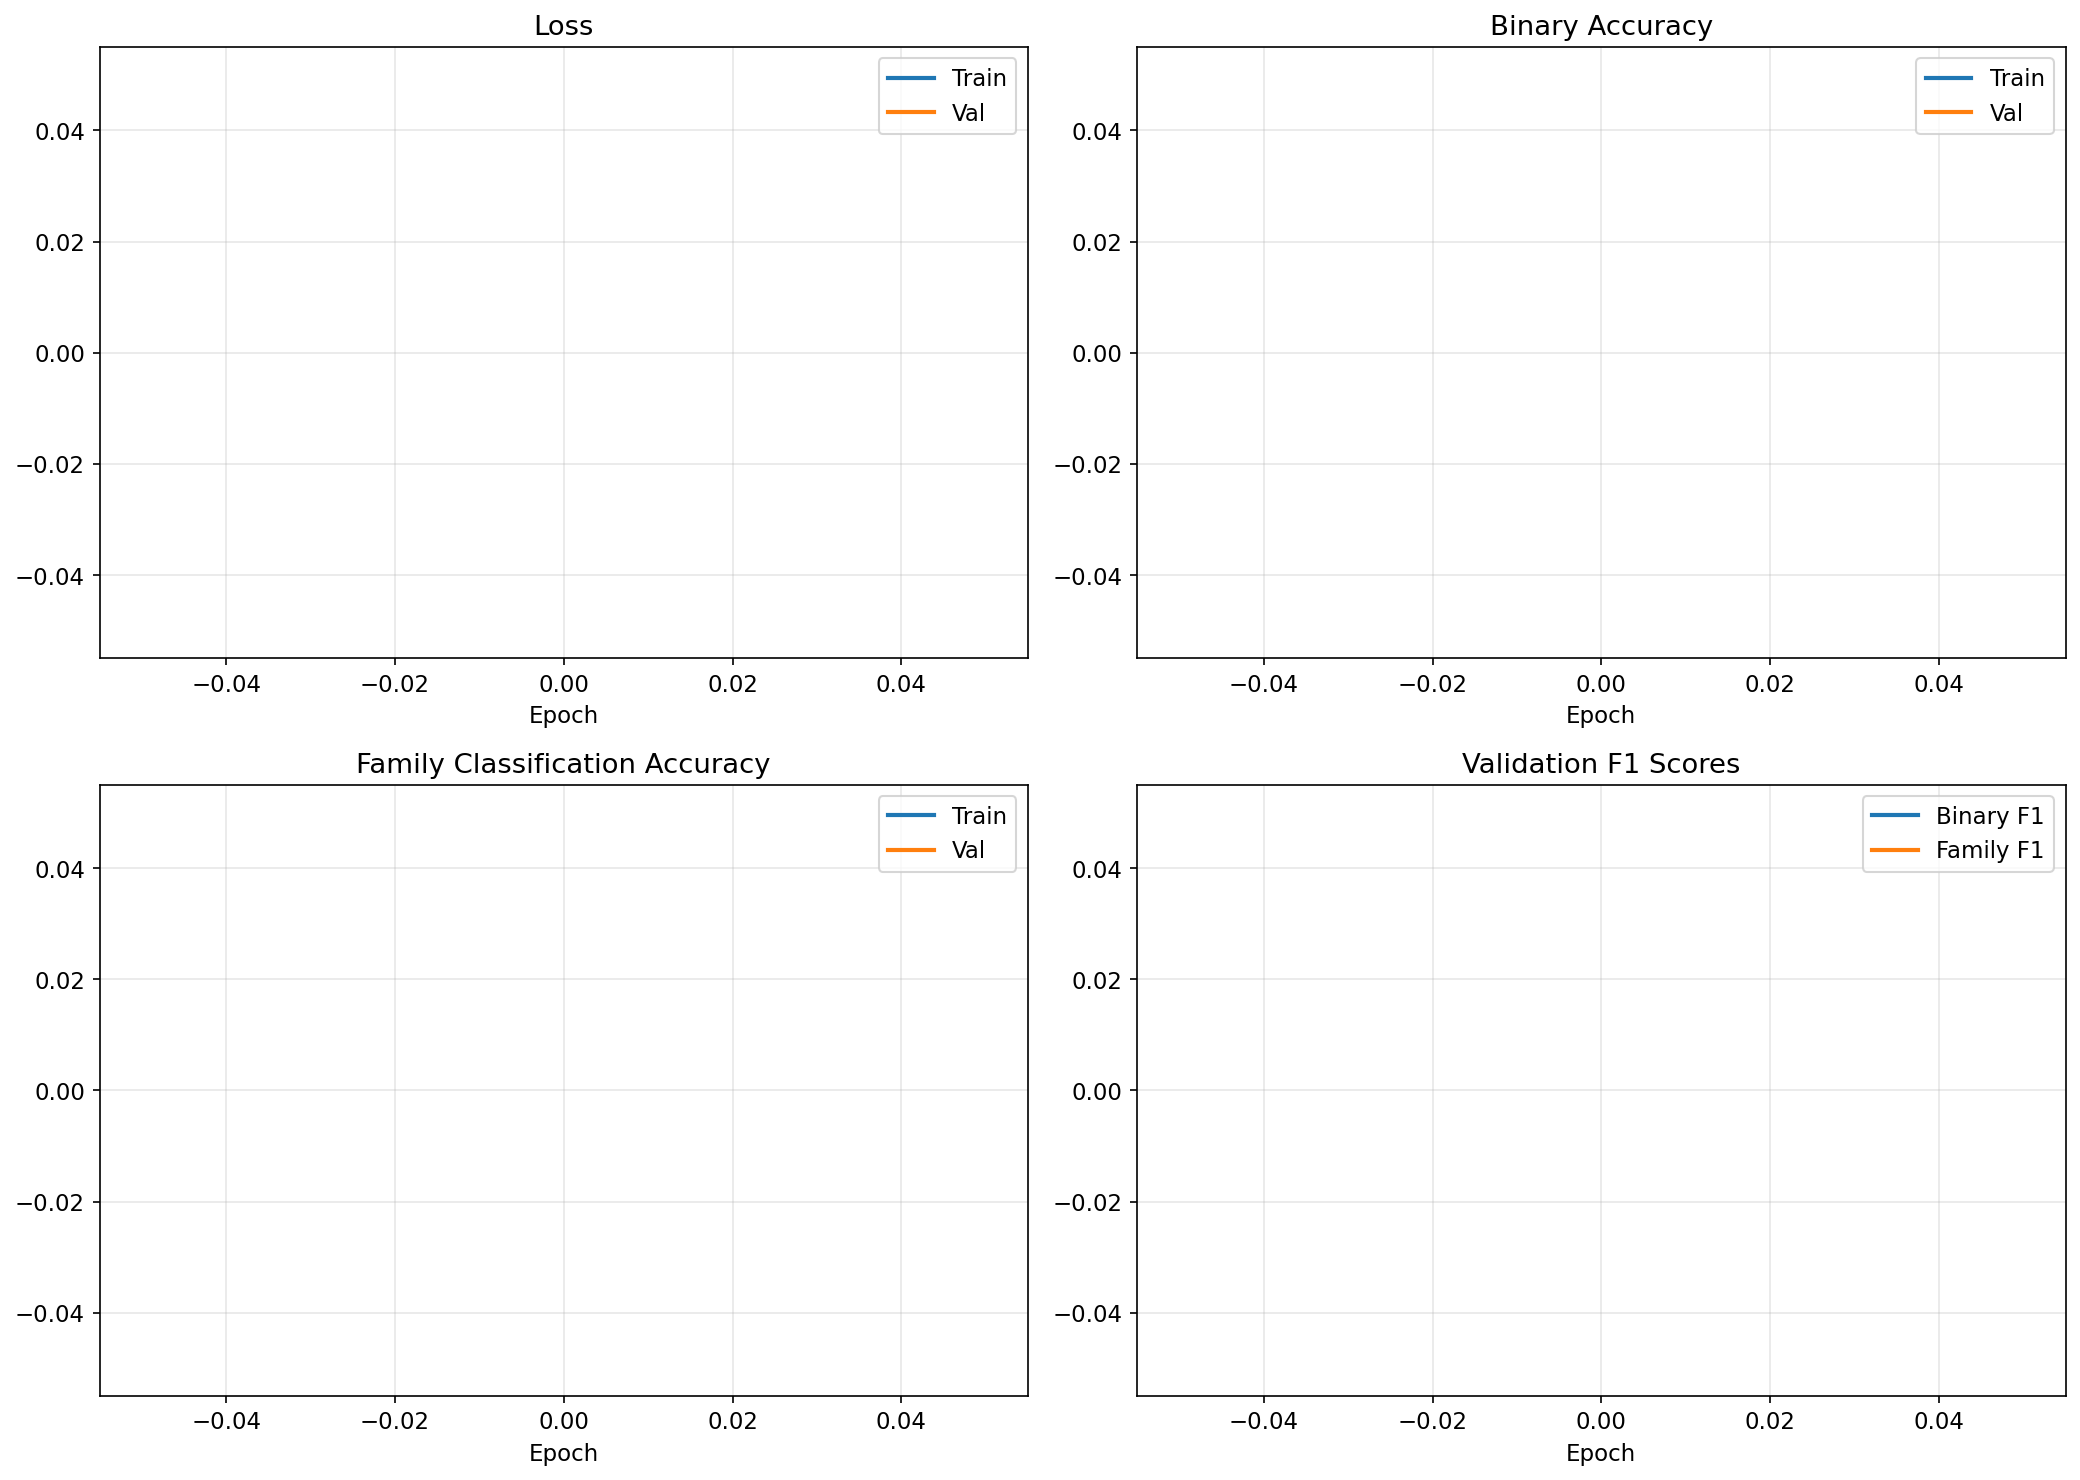

Saved: training_curves.png


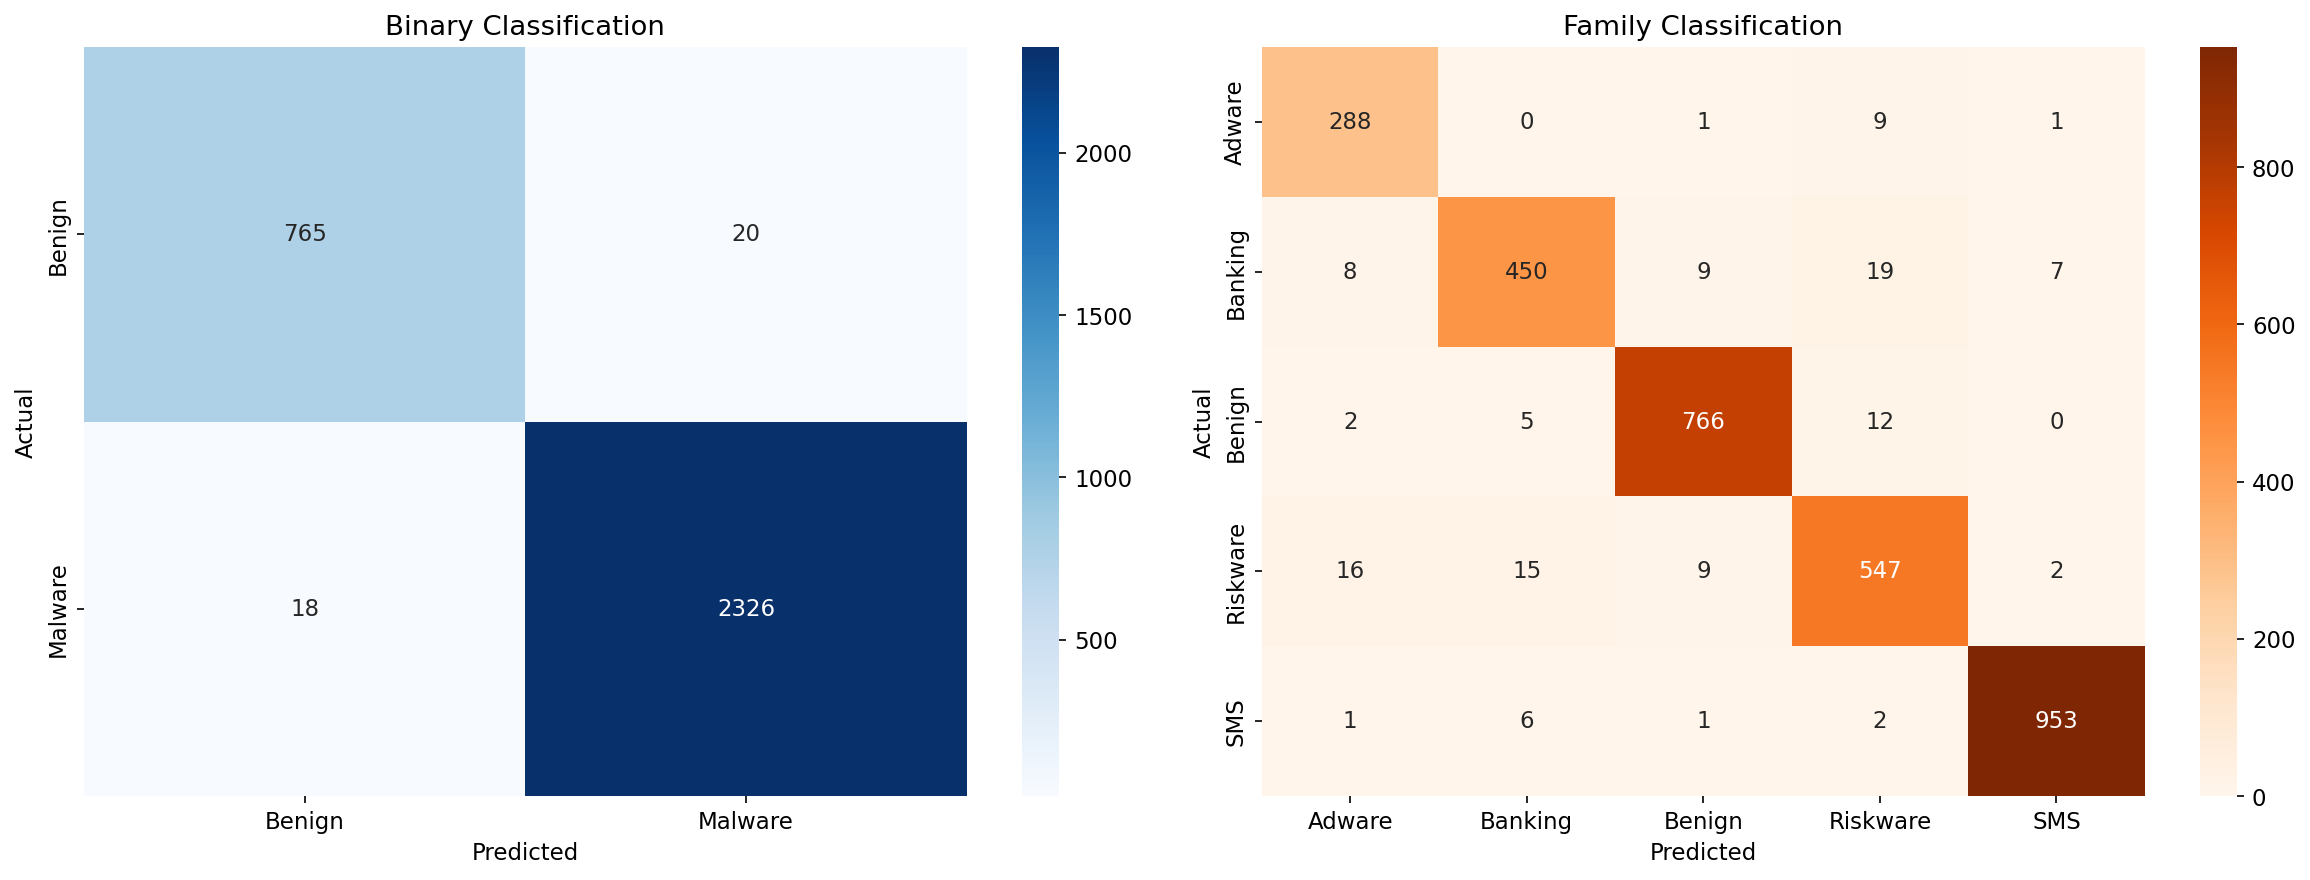

Saved: confusion_matrices.png


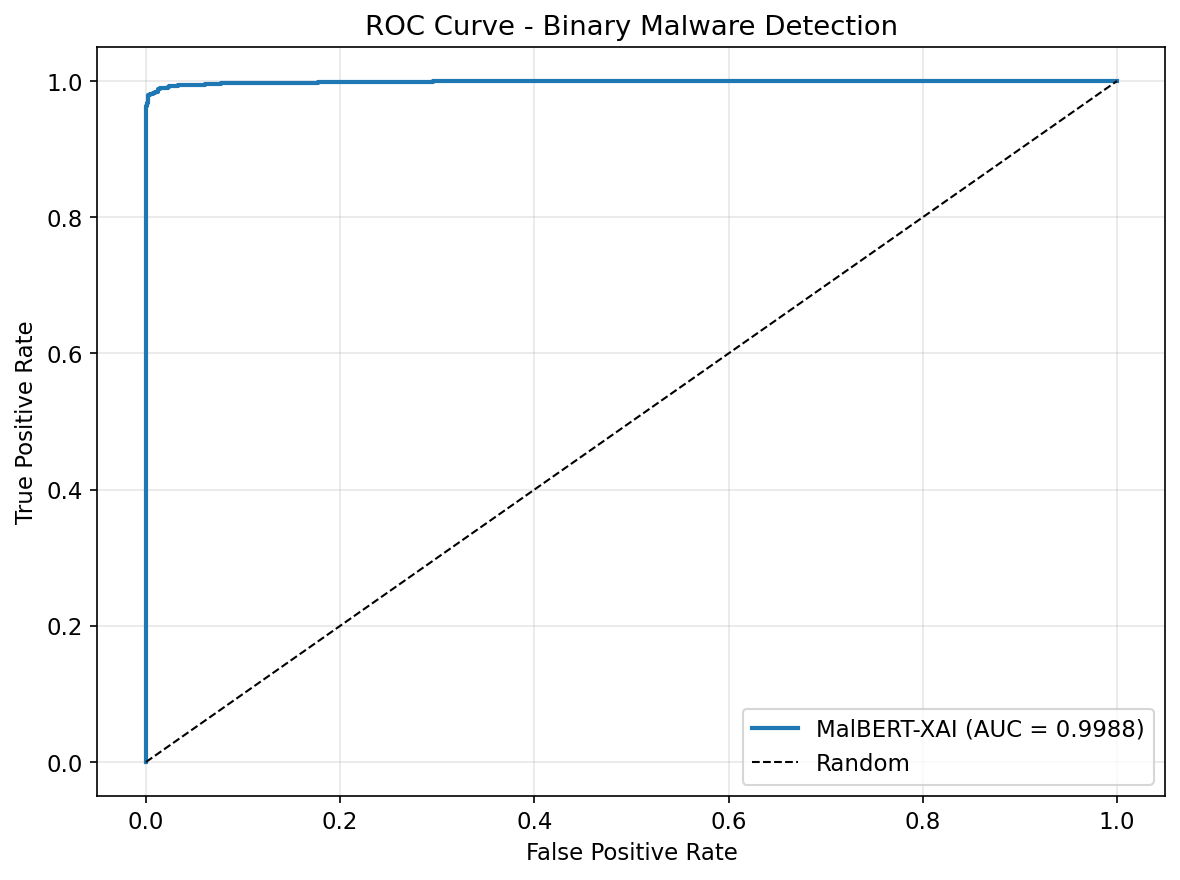

Saved: roc_curve.png


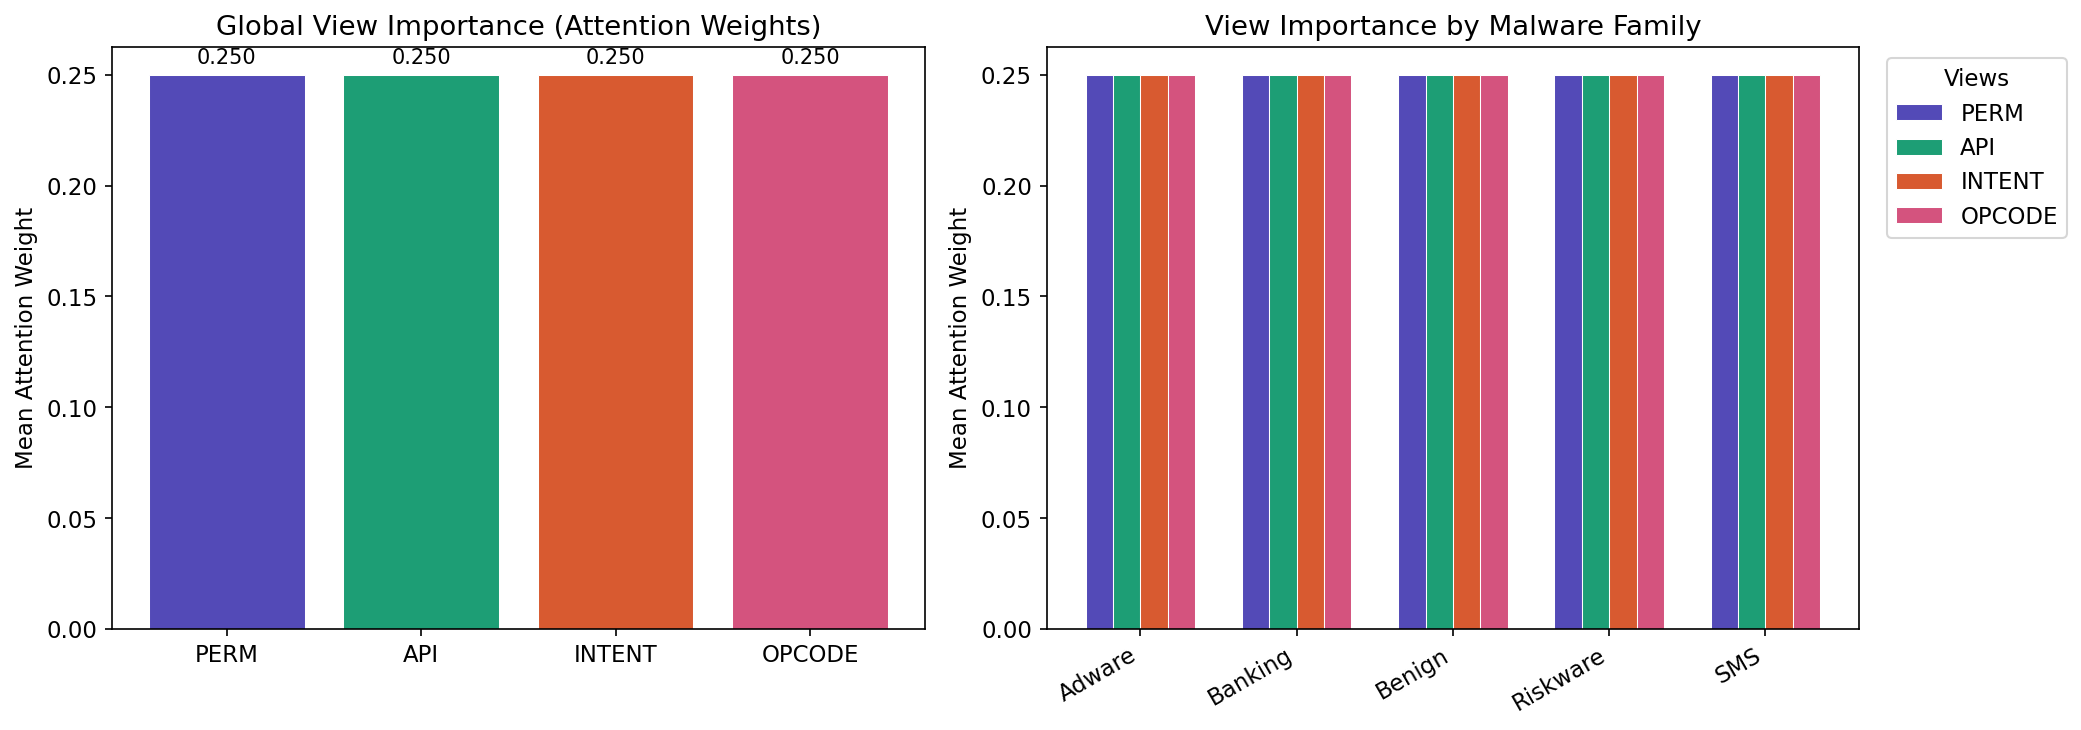

Saved: view_attention_analysis.png

All plots saved to: /content/drive/MyDrive/00 MalBert - Internship Project/malbert_xai_results


In [ ]:

# ╔═══════════════════════════════════════════════════════════════╗
# ║  CELL 8: GENERATE ALL PLOTS FOR THE PAPER                     ║
# ╚═══════════════════════════════════════════════════════════════╝

print("=" * 60)
print("[6/6] Generating plots...")
print("=" * 60)

plt.rcParams.update({"figure.dpi": 150, "font.size": 11})

# ── Plot 1: Training Curves ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history["train_loss"], label="Train", linewidth=2)
axes[0, 0].plot(history["val_loss"], label="Val", linewidth=2)
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history["train_binary_acc"], label="Train", linewidth=2)
axes[0, 1].plot(history["val_binary_acc"], label="Val", linewidth=2)
axes[0, 1].set_title("Binary Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(history["train_family_acc"], label="Train", linewidth=2)
axes[1, 0].plot(history["val_family_acc"], label="Val", linewidth=2)
axes[1, 0].set_title("Family Classification Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(history["val_binary_f1"], label="Binary F1", linewidth=2)
axes[1, 1].plot(history["val_family_f1"], label="Family F1", linewidth=2)
axes[1, 1].set_title("Validation F1 Scores")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "training_curves.png"), bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

# ── Plot 2: Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_binary = confusion_matrix(test_bin_labels, test_bin_preds)
sns.heatmap(cm_binary, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign", "Malware"], yticklabels=["Benign", "Malware"])
axes[0].set_title("Binary Classification")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

cm_family = confusion_matrix(test_fam_labels, test_fam_preds)
sns.heatmap(cm_family, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[1].set_title("Family Classification")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "confusion_matrices.png"), bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

# ── Plot 3: ROC Curve ──
if binary_auc > 0:
    fpr, tpr, _ = roc_curve(test_bin_labels, test_bin_probs[:, 1])
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f"MalBERT-XAI (AUC = {binary_auc:.4f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Binary Malware Detection")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, "roc_curve.png"), bbox_inches="tight")
    plt.show()
    print("Saved: roc_curve.png")

# ── Plot 4: View Attention Analysis (KEY NOVELTY FIGURE) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_attn = all_attn_weights.mean(axis=0)
colors = ["#534AB7", "#1D9E75", "#D85A30", "#D4537E"]

axes[0].bar(Config.VIEWS, mean_attn, color=colors, edgecolor="white", linewidth=0.5)
axes[0].set_title("Global View Importance (Attention Weights)")
axes[0].set_ylabel("Mean Attention Weight")
for i, v in enumerate(mean_attn):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)

family_attn = {}
for fam_id in range(Config.NUM_FAMILIES):
    mask = np.array(test_fam_labels) == fam_id
    if mask.sum() > 0:
        family_name = label_encoder.inverse_transform([fam_id])[0]
        family_attn[family_name] = all_attn_weights[mask].mean(axis=0)

family_df = pd.DataFrame(family_attn, index=Config.VIEWS).T
family_df.plot(kind="bar", ax=axes[1], width=0.7, color=colors, edgecolor="white", linewidth=0.5)
axes[1].set_title("View Importance by Malware Family")
axes[1].set_ylabel("Mean Attention Weight")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].legend(title="Views", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_DIR, "view_attention_analysis.png"), bbox_inches="tight")
plt.show()
print("Saved: view_attention_analysis.png")

print(f"\nAll plots saved to: {Config.OUTPUT_DIR}")
